# Система Лоренца

Система Лоренца — трёхмерная автономная система ОДУ:

\begin{cases}
\dot x = \sigma (y - x),\\[4pt]
\dot y = x(\rho - z) - y,\\[4pt]
\dot z = xy - \beta z,
\end{cases}


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks

%matplotlib inline

def lorenz(t, xyz, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = xyz
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

def integrate_lorenz(x0=(1.0, 1.0, 1.0),
                     t_span=(0.0, 50.0),
                     dt=0.01,
                     sigma=10.0, rho=28.0, beta=8.0/3.0,
                     rtol=1e-9, atol=1e-12):
    t_eval = np.arange(t_span[0], t_span[1] + dt, dt)
    sol = solve_ivp(lorenz, t_span, x0, args=(sigma, rho, beta),
                    method='RK45', dense_output=True, rtol=rtol, atol=atol)
    Y = sol.sol(t_eval)  # shape (3, N)
    return t_eval, Y.T  # (N,3)

def plot_time_series(t, Y, title='Lorenz: x(t), y(t), z(t)'):
    x, y, z = Y[:,0], Y[:,1], Y[:,2]
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(t, x); axes[0].set_ylabel('x(t)')
    axes[1].plot(t, y); axes[1].set_ylabel('y(t)')
    axes[2].plot(t, z); axes[2].set_ylabel('z(t)'); axes[2].set_xlabel('t')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_2d_projections(Y, title='2D фазовые портреты (x–y, x–z, y–z)'):
    x, y, z = Y[:,0], Y[:,1], Y[:,2]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(x, y, lw=0.6); axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].set_title('x–y')
    axes[1].plot(x, z, lw=0.6); axes[1].set_xlabel('x'); axes[1].set_ylabel('z'); axes[1].set_title('x–z')
    axes[2].plot(y, z, lw=0.6); axes[2].set_xlabel('y'); axes[2].set_ylabel('z'); axes[2].set_title('y–z')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


## Базовое моделирование (σ=10, ρ=28, β=8/3)

Интегрируем систему Лоренца для стандартных хаотических параметров и строим:
- Временные ряды x(t), y(t), z(t);
- 2D-фазовые портреты в трёх плоскостях.

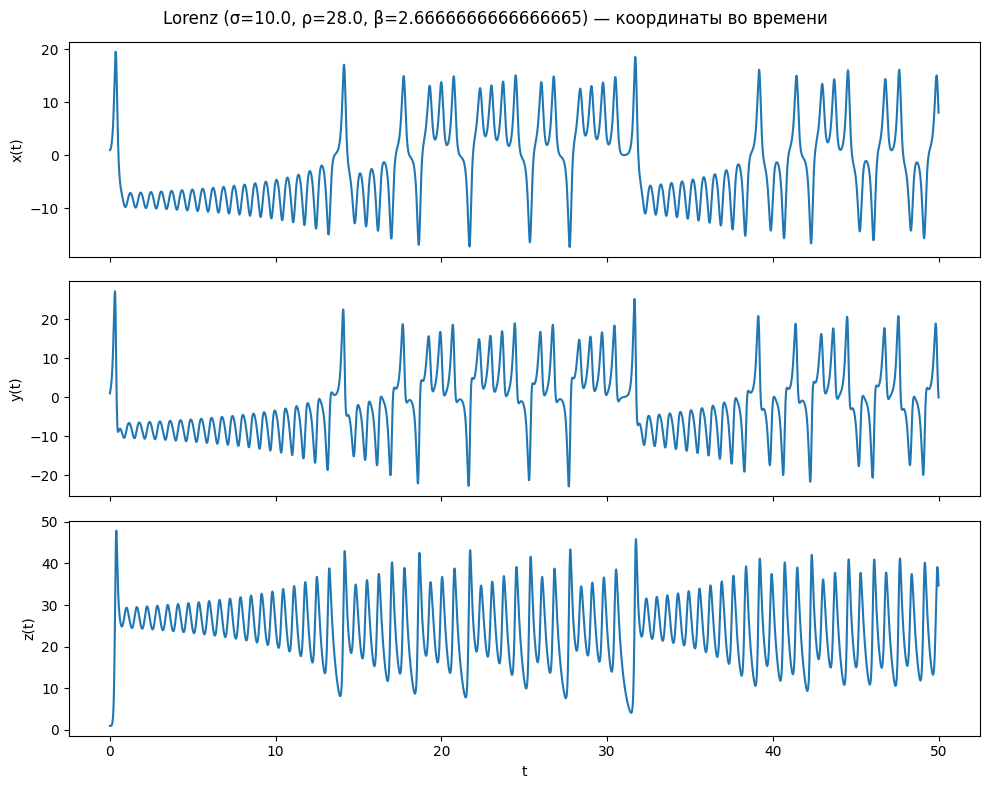

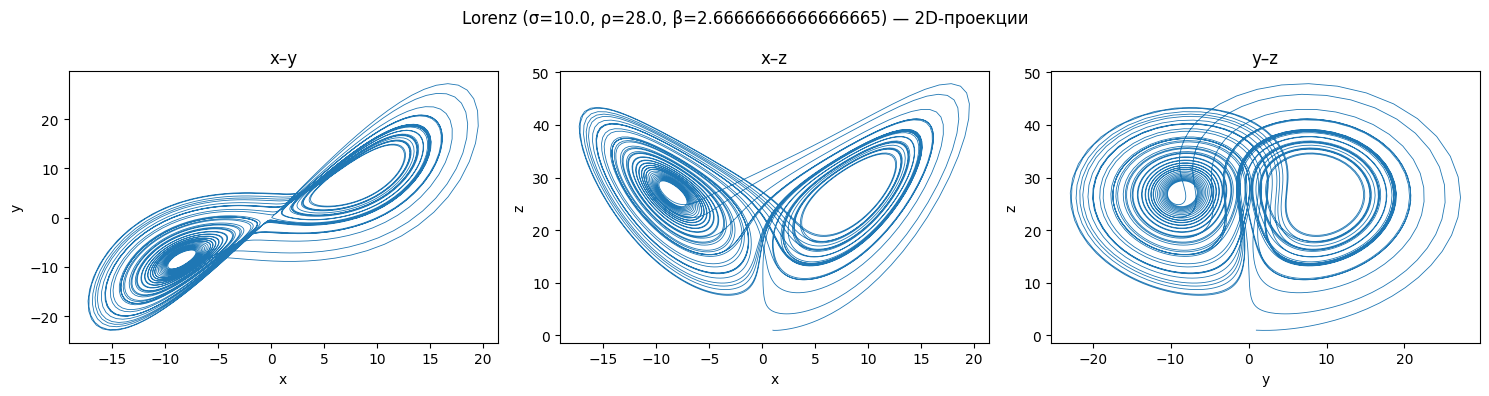

In [2]:
sigma, rho, beta = 10.0, 28.0, 8.0/3.0
t, Y = integrate_lorenz(x0=(1.0, 1.0, 1.0), t_span=(0, 50), dt=0.01,
                        sigma=sigma, rho=rho, beta=beta)
plot_time_series(t, Y, title=f'Lorenz (σ={sigma}, ρ={rho}, β={beta}) — координаты во времени')
plot_2d_projections(Y, title=f'Lorenz (σ={sigma}, ρ={rho}, β={beta}) — 2D-проекции')


## Чувствительность к начальным условиям

Решим систему для двух почти одинаковых начальных условий, отличающихся на `ε` (например, ε=1e-8) по компоненте x.
Посмотрим на норму разности траекторий `||δ(t)||`. На начальном участке график должен быть примерно линейным.


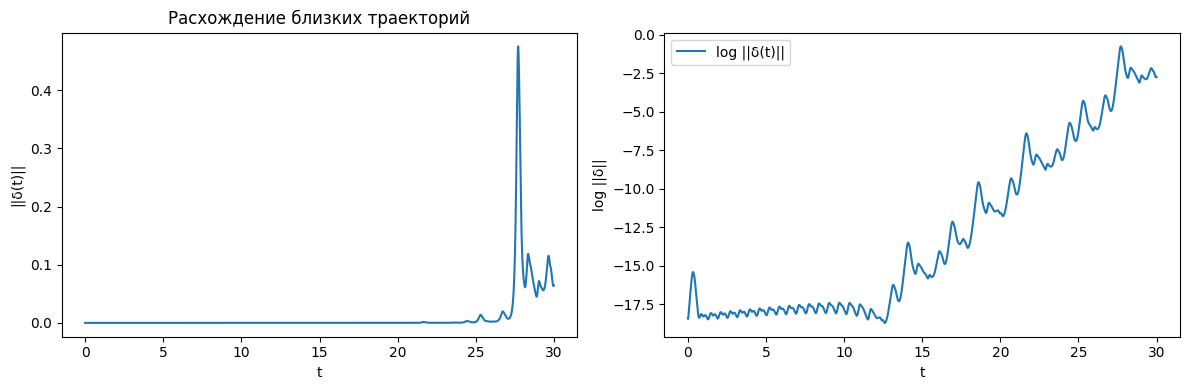

In [3]:
eps = 1e-8
x0a = (1.0, 1.0, 1.0)
x0b = (1.0 + eps, 1.0, 1.0)

t_long, Ya = integrate_lorenz(x0=x0a, t_span=(0, 30), dt=0.005, sigma=sigma, rho=rho, beta=beta)
_,     Yb = integrate_lorenz(x0=x0b, t_span=(0, 30), dt=0.005, sigma=sigma, rho=rho, beta=beta)

delta = np.linalg.norm(Ya - Yb, axis=1)

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(t_long, delta)
ax[0].set_xlabel('t'); ax[0].set_ylabel('||δ(t)||'); ax[0].set_title('Расхождение близких траекторий')

mask = (t_long > 1.0) & (t_long < 5.0)
coef = np.polyfit(t_long[mask], np.log(delta[mask]), 1)
lam_est = coef[0]

ax[1].plot(t_long, np.log(delta), label='log ||δ(t)||')
ax[1].set_xlabel('t'); ax[1].set_ylabel('log ||δ||');
ax[1].legend()
plt.tight_layout()
plt.show()

## Аттрактор при разных значениях ρ

Варьируем ρ и смотрим на форму аттрактора.
- При малых ρ траектории стремятся к устойчивым стационарным точкам.
- При ρ≈24.74 происходит потеря устойчивости (бифуркация Хопфа / переход к сложной динамике).
- При ρ≈28 наблюдаем классический хаос.


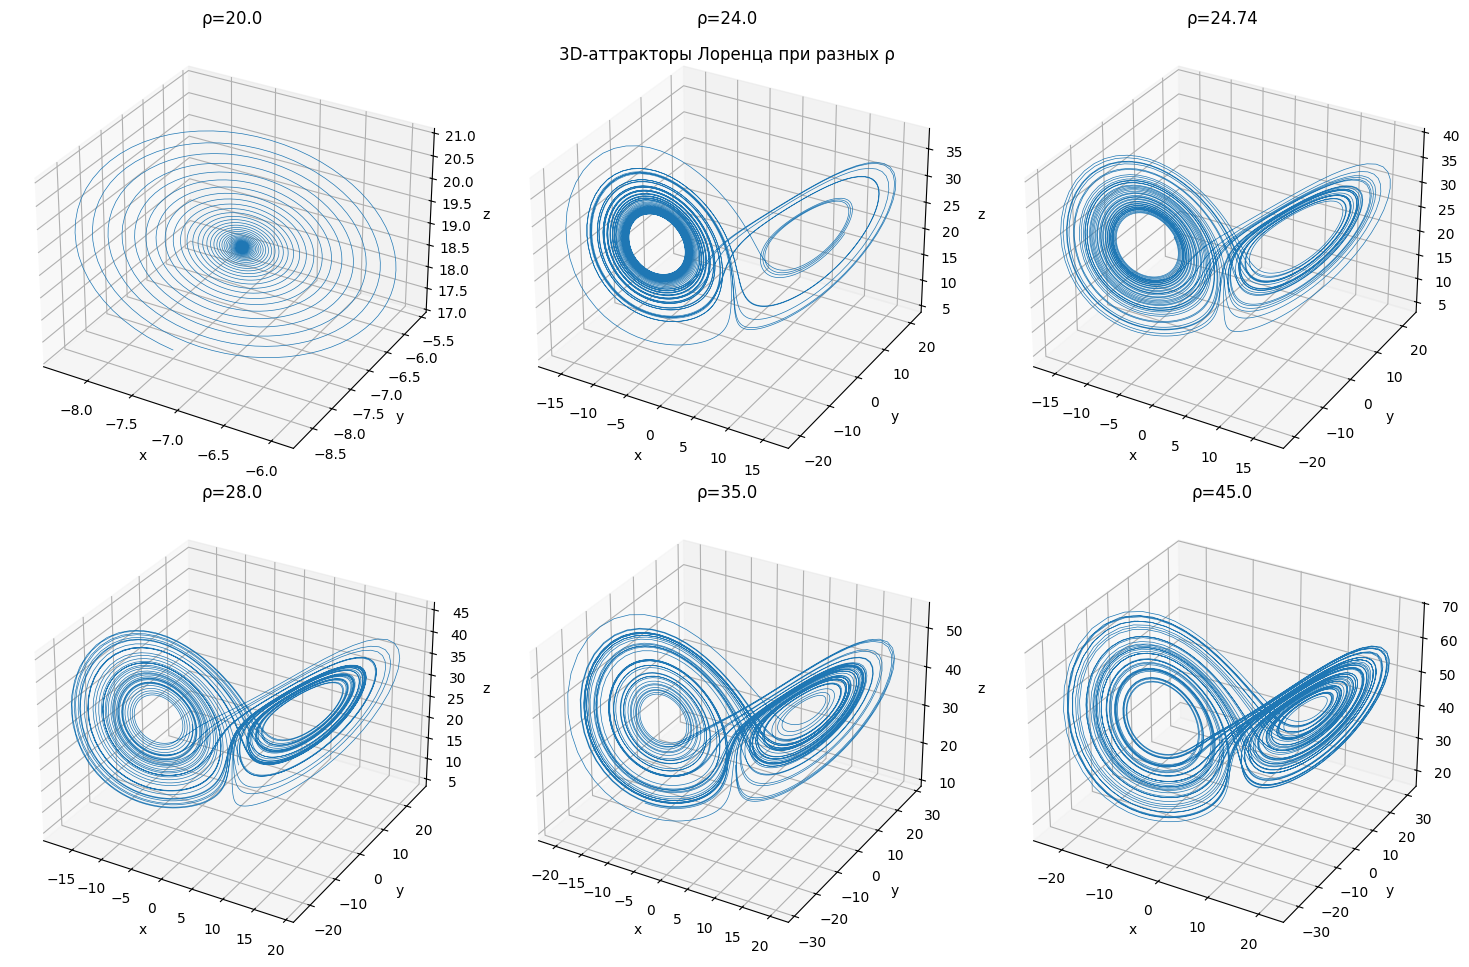

In [4]:
from mpl_toolkits.mplot3d import Axes3D

rho_list = [20.0, 24.0, 24.74, 28.0, 35.0, 45.0]
fig = plt.figure(figsize=(15, 10))

for i, r in enumerate(rho_list, 1):
    tR, YR = integrate_lorenz(x0=(1.0, 1.0, 1.0), t_span=(0, 60), dt=0.01, sigma=sigma, rho=r, beta=beta)
    mask = tR >= 10.0
    ax = fig.add_subplot(2, 3, i, projection='3d')
    ax.plot(YR[mask,0], YR[mask,1], YR[mask,2], lw=0.5)
    ax.set_title(f'ρ={r}')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

fig.suptitle('3D-аттракторы Лоренца при разных ρ', y=0.92)
plt.tight_layout()
plt.show()

## Бифуркационная диаграмма (по максимумам x)

Строим диаграмму вида: по горизонтали ρ, по вертикали — локальные максимумы x(t) после отбрасывания транзиента.
- Для периодических режимов количество точек конечное.
- В хаосе множество максимумов заполняет интервал.


In [5]:
from tqdm import tqdm
def bifurcation_data(rho_values, t_span=(0, 120), dt=0.01, drop_transient=60.0,
                     sigma=10.0, beta=8.0/3.0, prominence=1.0):
    r_list = []
    x_peaks_list = []
    for r in tqdm(rho_values):
        tR, YR = integrate_lorenz(x0=(1.0, 1.0, 1.0), t_span=t_span, dt=dt, sigma=sigma, rho=r, beta=beta)
        mask = tR >= drop_transient
        x = YR[mask,0]
        # ищем локальные максимумы
        idx, _ = find_peaks(x, prominence=prominence)
        peaks = x[idx]
        # сохраняем пары (rho, peak)
        r_list.append(np.full_like(peaks, r, dtype=float))
        x_peaks_list.append(peaks)
    if len(r_list)==0:
        return np.array([]), np.array([])
    return np.concatenate(r_list), np.concatenate(x_peaks_list)

100%|██████████| 50/50 [01:19<00:00,  1.59s/it]


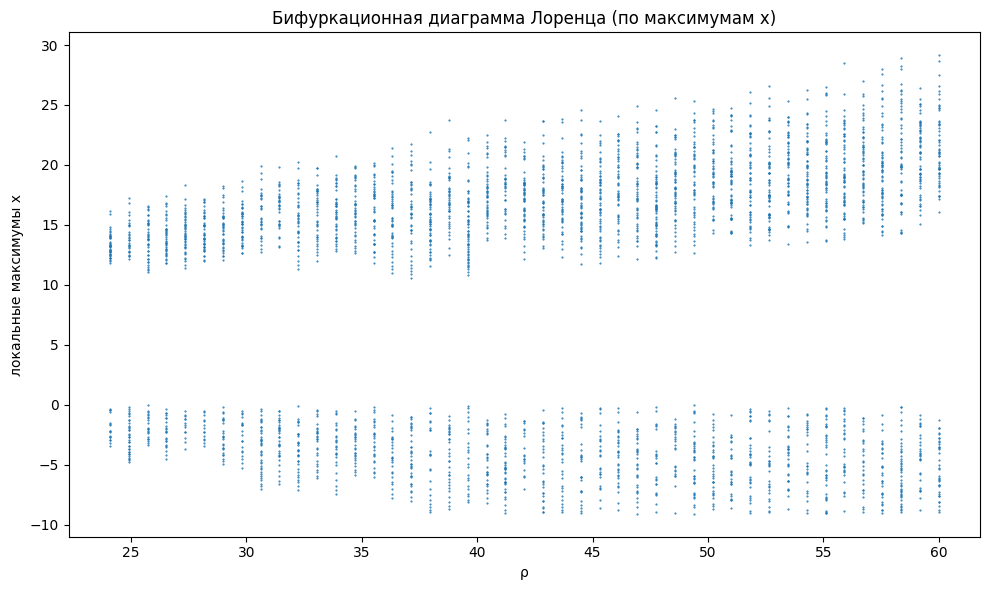

In [9]:
rho_values = np.linspace(20, 60, 50)  # шаг ~0.25
R, Xmax = bifurcation_data(rho_values, t_span=(0, 120), dt=0.01, drop_transient=60.0, prominence=1.0)

plt.figure(figsize=(10,6))
plt.plot(R, Xmax, '.', markersize=1)
plt.xlabel('ρ'); plt.ylabel('локальные максимумы x')
plt.title('Бифуркационная диаграмма Лоренца (по максимумам x)')
plt.tight_layout()
plt.show()

## Сечения Пуанкаре

Сечение по плоскости `z = ρ − 1`, учитываем пересечения при движении **вверх** (`dz/dt > 0`).  
Выводим точки пересечения в координатах (x, y).  
- Для периодического режима ожидается конечное число точек.
- Для хаотического — облако.

Алгоритм:
1. Находим пары соседних моментов времени, где `z - (ρ - 1)` меняет знак с минуса на плюс.
2. По линейной интерполяции оцениваем координаты в момент пересечения.



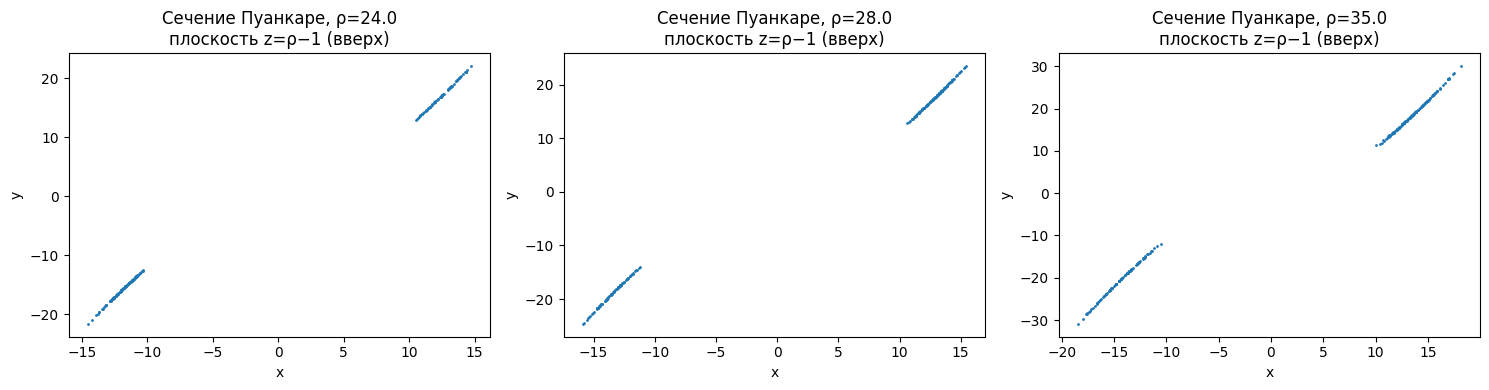

In [ ]:
def poincare_section(t, Y, rho, plane_z=None, upwards=True):
    """Возвращает массив точек (x,y) пересечения с плоскостью z=plane_z (по умолчанию ρ-1)."""
    if plane_z is None:
        plane_z = rho - 1.0
    x, y, z = Y[:,0], Y[:,1], Y[:,2]
    s = z - plane_z
    # индексы, где происходит переход через 0 в нужном направлении
    idxs = np.where((s[:-1] < 0) & (s[1:] >= 0))[0] if upwards else np.where((s[:-1] > 0) & (s[1:] <= 0))[0]
    pts = []
    for i in idxs:
        # линейная интерполяция по s
        s0, s1 = s[i], s[i+1]
        if s1 == s0:
            continue
        alpha = -s0 / (s1 - s0)  # доля между i и i+1
        xi = x[i] + alpha * (x[i+1] - x[i])
        yi = y[i] + alpha * (y[i+1] - y[i])
        # можно также проверить знак dz/dt в точке, но приближаем направлением по s
        pts.append([xi, yi])
    return np.array(pts)

# Сравним сечения для "почти периодического" и хаотического режимов
rho_set = [24.0, 28.0, 35.0]  # 24 ближе к порогу, 28 классический хаос, 35 более "бурный" хаос
fig, axes = plt.subplots(1, len(rho_set), figsize=(15,4))
for ax, r in zip(axes, rho_set):
    tR, YR = integrate_lorenz(x0=(1.0, 1.0, 1.0), t_span=(0, 200), dt=0.005, sigma=sigma, rho=r, beta=beta)
    mask = tR >= 50.0  # отбросим транзиент
    pts = poincare_section(tR[mask], YR[mask], rho=r, plane_z=r-1.0, upwards=True)
    if pts.size:
        ax.plot(pts[:,0], pts[:,1], '.', markersize=2)
    ax.set_title(f'Сечение Пуанкаре, ρ={r}\nплоскость z=ρ−1 (вверх)')
    ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout()
plt.show()


# Переход к хаосу

При фиксированных $ \sigma = 10 $ и $ \beta = \tfrac{8}{3} $ динамика системы Лоренца изменяется при увеличении параметра $ \rho $:

- **$1 < \rho < \rho_H$** — устойчивые равновесия $C_\pm$, все колебания затухают.  
- **$\rho \approx \rho_H \simeq 24.74$** — равновесия $C_\pm$ теряют устойчивость, возникают периодические колебания.  
- **$\rho \gtrsim \rho_H$** — колебания усложняются, возникает переход к хаотическому режиму (странный аттрактор Лоренца).


100%|██████████| 81/81 [01:07<00:00,  1.20it/s]


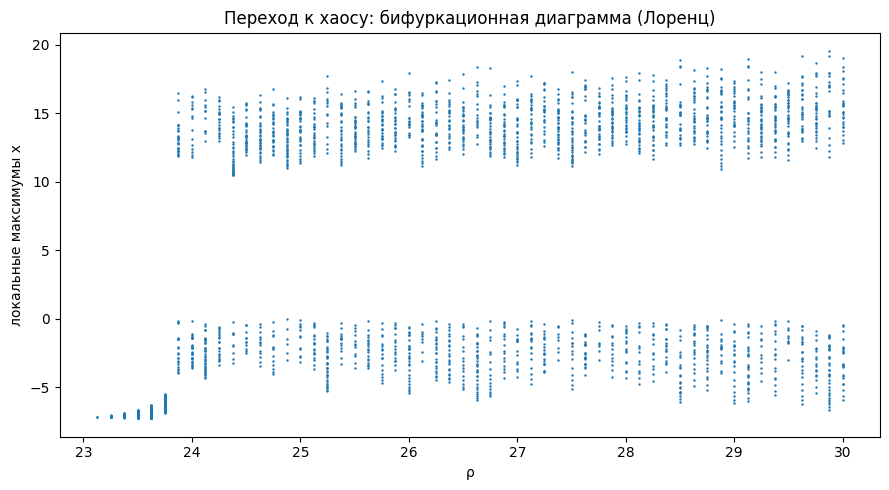

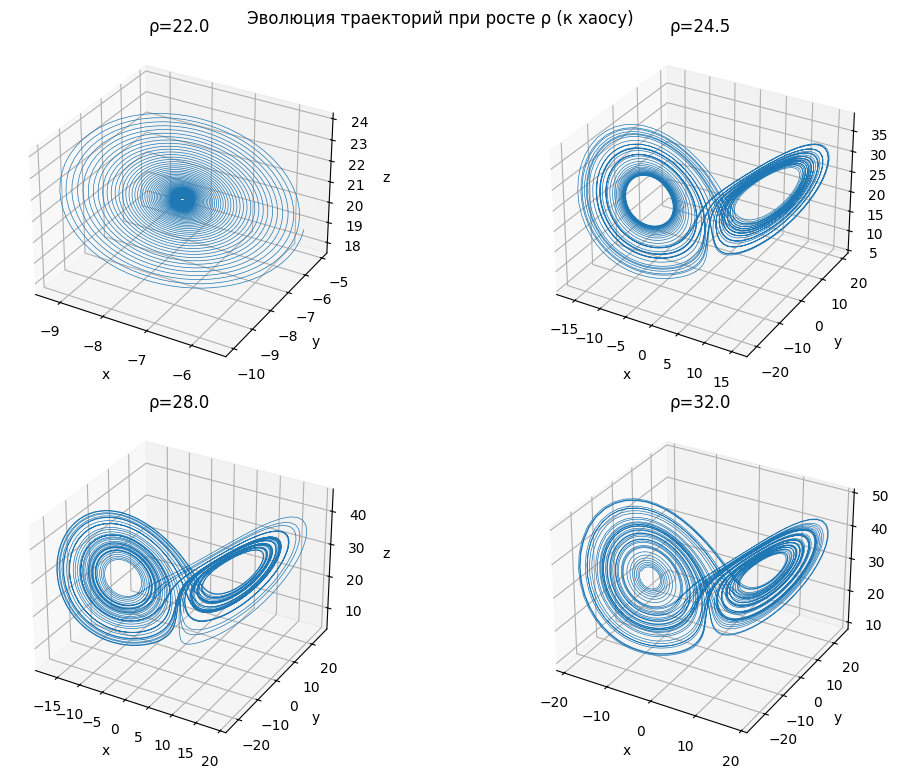

In [10]:
rho_values = np.linspace(20, 30, 81)  # компактный диапазон вокруг порога
R, Xmax = bifurcation_data(rho_values, t_span=(0, 90), dt=0.01, drop_transient=45.0, prominence=1.0)

plt.figure(figsize=(9,5))
plt.plot(R, Xmax, '.', markersize=1.5)
plt.xlabel('ρ'); plt.ylabel('локальные максимумы x')
plt.title('Переход к хаосу: бифуркационная диаграмма (Лоренц)')
plt.tight_layout()
plt.show()

from mpl_toolkits.mplot3d import Axes3D

rho_gallery = [22.0, 24.5, 28.0, 32.0]
fig = plt.figure(figsize=(12, 8))
for i, r in enumerate(rho_gallery, 1):
    tG, YG = integrate_lorenz(x0=(1.0, 1.0, 1.0), t_span=(0, 60), dt=0.01, rho=r)
    mask = tG >= 10.0
    ax = fig.add_subplot(2, 2, i, projection='3d')
    ax.plot(YG[mask,0], YG[mask,1], YG[mask,2], lw=0.5)
    ax.set_title(f'ρ={r}')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
fig.suptitle('Эволюция траекторий при росте ρ (к хаосу)', y=0.95)
plt.tight_layout()
plt.show()
